# Streaming Glacier Directories

OGGM distributes pre-processed glacier directories at six processing levels (L0 to L5), so that users can start a workflow from whichever stage suits their application (see the [getting started with pre-processed directories](https://tutorials.oggm.org/stable/notebooks/10minutes/preprocessed_directories.html) tutorial for an introduction, and the [OGGM-Shop tutorial](https://tutorials.oggm.org/stable/notebooks/10minutes/machine_learning.html) for how OGGM downloads external data in general).

Two format generations of these directories exist:

- The **incremental format** (`format_version: 1`) replaced cumulative per-level archives with *deltas and manifests*, so that a client only downloads what each level actually changed. It is demonstrated in the companion notebook [incremental_gdirs.ipynb](incremental_gdirs.ipynb).
- The **streaming format** (`format_version: 2`), demonstrated here, additionally changes *what is inside* a glacier directory and *how it is packaged*, with one goal: any piece of a glacier directory, whether a manifest, a climate time series, or a gridded variable, can be read **directly off the server with HTTP range requests, without downloading the archive at all**.

The sections below cover how the format achieves that, the conversion of a small piece of the published legacy reference dataset into the streaming format, the standard `init_glacier_directories` workflow run against it, and finally streaming data from a real server.

In [ ]:
!pip install "oggm[full] @git+https://github.com/gampnico/oggm.git@feat-ON-95-stream-glacier-directories"
# !uv pip install "oggm[full] @git+https://github.com/gampnico/oggm.git@feat-ON-95-stream-glacier-directories"

## TL;DR

- Streaming-format glacier directories store array data (gridded, climate) and the former pickle objects (flowlines, geometries, and so on) as **zarr groups** inside a single per-glacier `data_store.zarr` store, and vector data as **GeoParquet**.
- Archives are **uncompressed (STORED) zip-in-zip bundles**: because nothing is compressed, every file in the archive corresponds to a fixed HTTP byte range of the bundle. The format is streamable by construction.
- The user-facing API is unchanged: `workflow.init_glacier_directories(..., from_prepro_level=n, prepro_base_url=...)`. The client probes for `.zip` bundles first and falls back to the classic `.tar` bundles transparently, so old servers and old datasets keep working.
- `utils._downloads.peek_remote_manifest` and `utils._downloads.open_remote_group` read a manifest, or lazily open a zarr group, out of a remote bundle via HTTP range requests, without downloading anything to disk.
- Existing published datasets can be converted with two functions from `oggm.utils.compat`: `convert_prepro_to_deltas(..., convert_to_zarr=True)` (legacy to incremental v1, pickles to zarr) and `convert_prepro_to_v2_artifacts` (v1 to v2 streaming artifacts).
- The cost of addressability is the lost compression: v2 bundles are larger on disk and on the wire than the equivalent `.tar.gz` ones, so the format only pays off for clients which read a fraction of a directory.

## How the Streaming System Works

### Payload: Zarr Groups and GeoParquet Instead of NetCDF, Pickles, and Shapefiles

A classic (v1) glacier directory is a folder of heterogeneous files: NetCDF files for gridded and climate data, Python pickles for the model objects (centerlines, flowlines, and geometries), and zipped ESRI shapefiles for vector data. None of these are friendly to partial remote reads: NetCDF and pickle files must be present as local files, or downloaded in full, and a compressed shapefile tar cannot be indexed into.

A streaming-format (v2) directory replaces them:

| v1 payload | v2 payload | read with |
|---|---|---|
| `gridded_data.nc`, `climate_historical.nc`, `gcm_data.nc` | groups in `data_store.zarr` | `gdir.open_group(basename)` |
| `*.pkl` object pickles | groups in `data_store.zarr` | `gdir.read_store(basename)` (unchanged call) |
| `outlines.shp` (+ tar) | `outlines.parquet` (GeoParquet) | `gdir.read_shapefile(basename)` (unchanged call) |

With zarr, reading one variable means fetching a handful of small, individually addressable objects, which suits HTTP range requests. Files with no streaming benefit (the DEM GeoTIFF, the JSON and CSV diagnostics, and the model-run output NetCDFs) are unchanged.

### Container: Uncompressed Zip-in-zip Bundles

OGGM currently groups the per-glacier archives of up to 100 glaciers into *bundles* for distribution. The v2 container keeps that layout but changes the packaging:

- each glacier becomes an **uncompressed** `{rgi_id}.zip`,
- up to 100 of them are placed inside an outer `{bundle}.zip`,
- both layers use zip64, and an `L{n}.manifest.json` in each glacier archive carries `format_version: 2`.

Because both zip layers are uncompressed, the byte offset of every file inside the outer bundle can be computed from the zip central directories alone. A remote reader fetches the central directories (a few KiB), then addresses any member, whether a manifest, a zarr metadata document, or a single array chunk, with a plain HTTP range request. Compression is deliberately traded away for addressability, which is an acceptable price given that most of the data are already compressed.

### Deltas and Manifests

The incremental level system is unchanged. To recap: levels ship as *deltas* on top of lower levels, *materialisations* bundle several levels into one self-sufficient artifact, and L5 is a *standalone* mini directory. Every artifact self-documents through its manifest ([incremental_gdirs.ipynb](incremental_gdirs.ipynb) covers this in detail). A directory must never mix `format_version` 1 and 2 artifacts, however, so OGGM refuses to layer across format versions, which is also why converted v2 datasets get a fresh `dataset_id` of their own.

## Setup

The usual OGGM initialisation.

In [2]:
import json
import os
import zipfile

import matplotlib.pyplot as plt
import xarray as xr

from oggm import cfg, tasks, utils, workflow
from oggm.utils import _downloads, compat

cfg.initialize(logging_level="WARNING")
cfg.PARAMS["use_multiprocessing"] = True

base_dir = utils.gettempdir(dirname="OGGM-streaming-gdirs", reset=True)
base_dir

2026-09-16 13:42:09: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-09-16 13:42:09: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-09-16 13:42:09: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-09-16 13:42:09: oggm.cfg: Multiprocessing switched ON after user settings.


'/tmp/OGGM/OGGM-streaming-gdirs'

## Converting a Published Dataset to the Streaming Format

The OGGM cluster serves the published pre-processed directories in the legacy cumulative format. To obtain streaming artifacts we therefore convert a small subset of the published reference dataset locally, in two steps:

1. **Cumulative to incremental v1, with zarr payloads.** `compat.convert_prepro_to_deltas` downloads each level of the requested glaciers, diffs successive levels, and writes a delta-format server tree. Passing `convert_to_zarr=True` additionally rewrites each glacier's pickle files into its `data_store.zarr` store, and removes the pickles before archiving. This preserves all information, after which the manifests list `zarr_groups` alongside plain files.
2. **Incremental v1 to streaming v2.** `compat.convert_prepro_to_v2_artifacts` takes that local delta tree, layers each glacier level by level, converts every layered state to the v2 payload formats, and repackages everything as zip bundles with `format_version: 2` manifests, carrying over each level's kind, requires, and includes.

This is the same procedure you could run once on the cluster to republish an existing dataset in the streaming format.

We use the same two test glaciers as the incremental notebook. L0 to L2 and L3 to L5 of the reference dataset live in two different source trees, which is why the converter takes one base URL per level. They still form one logical dataset, identified by the explicit `dataset_tag`. Step 1 downloads six levels for two glaciers, so this cell can take a few minutes:

In [3]:
rgi_ids = [
    "RGI60-11.00897",  # Hintereisferner (Austrian Alps)
    "RGI60-01.16195",  # Alaska region
]

L12_BASE_URL = (
    "https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/"
    "L1-L2_files/2025.6/elev_bands/"
)
L35_BASE_URL = utils.DEFAULT_BASE_URL
base_urls = {
    0: L12_BASE_URL,
    1: L12_BASE_URL,
    2: L12_BASE_URL,
    3: L35_BASE_URL,
    4: L35_BASE_URL,
    5: L35_BASE_URL,
}

dataset_tag = "oggm_v1.6_2025.6_elev_bands_w5e5"
delta_dir = os.path.join(base_dir, "delta_server")

delta_root = compat.convert_prepro_to_deltas(
    rgi_ids=rgi_ids,
    base_urls=base_urls,
    border=80,
    rgi_version="62",
    workdir=utils.mkdir(os.path.join(base_dir, "convert_workdir")),
    output_dir=delta_dir,
    dataset_tag=dataset_tag,
    convert_to_zarr=True,
)
delta_root

2026-09-16 13:42:09: oggm.workflow: init_glacier_directories from prepro level 0 on 2 glaciers.
2026-09-16 13:42:09: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


2026-09-16 13:42:10: oggm.workflow: init_glacier_directories from prepro level 1 on 2 glaciers.
2026-09-16 13:42:10: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:42:11: oggm.workflow: init_glacier_directories from prepro level 2 on 2 glaciers.
2026-09-16 13:42:11: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:42:13: oggm.workflow: init_glacier_directories from prepro level 3 on 2 glaciers.
2026-09-16 13:42:13: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:42:15: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-09-16 13:42:15: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:42:18: oggm.workflow: init_glacier_directories from prepro level 5 on 2 glaciers.
2026-09-16 13:42:18: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


'/tmp/OGGM/OGGM-streaming-gdirs/delta_server/RGI62/b_080'

Step 2 turns the incremental tree into streaming artifacts. Note the new dataset tag: the converted artifacts are a distinct logical dataset. The format differs, and v1 and v2 levels can never layer together, so they get their own `dataset_id`:

In [4]:
v2_dataset_tag = dataset_tag + "_v2"
v2_dir = os.path.join(base_dir, "stream_server")

v2_root = compat.convert_prepro_to_v2_artifacts(
    delta_dir,
    rgi_ids,
    v2_dir,
    dataset_tag=v2_dataset_tag,
    border=80,
    rgi_version="62",
)
v2_root

'/tmp/OGGM/OGGM-streaming-gdirs/stream_server/RGI62/b_080'

The converter produced a complete streaming-format server tree with the same level layout, but `.zip` bundles instead of `.tar`:

In [5]:
for root, dirs, files in sorted(os.walk(v2_root)):
    for file in sorted(files):
        path = os.path.join(root, file)
        rel = os.path.relpath(path, v2_root)
        print(f"{os.path.getsize(path) / 1024:7.1f} KiB  {rel}")

   44.0 KiB  L0/RGI60-01/RGI60-01.161.zip
   55.6 KiB  L0/RGI60-11/RGI60-11.008.zip
  159.2 KiB  L1/RGI60-01/RGI60-01.161.zip
  165.7 KiB  L1/RGI60-11/RGI60-11.008.zip
  369.8 KiB  L2/RGI60-01/RGI60-01.161.zip
  384.7 KiB  L2/RGI60-11/RGI60-11.008.zip
  676.1 KiB  L3/RGI60-01/RGI60-01.161.zip
  708.5 KiB  L3/RGI60-11/RGI60-11.008.zip
  450.9 KiB  L4/RGI60-01/RGI60-01.161.zip
 1034.4 KiB  L4/RGI60-11/RGI60-11.008.zip
  539.1 KiB  L5/RGI60-01/RGI60-01.161.zip
  579.6 KiB  L5/RGI60-11/RGI60-11.008.zip


## Inside a v2 Bundle

We open Hintereisferner's L3 bundle and look at the packaging. Both zip layers are uncompressed, which makes every member remotely addressable:

In [6]:
rid = rgi_ids[0]
region = rid[:-6]  # 'RGI60-11'
bundle = f"{region}.{rid[-5:-2]}"  # 'RGI60-11.008', the 100-glacier bundle


def v2_bundle_path(level):
    return os.path.join(v2_root, f"L{level}", region, f"{bundle}.zip")


with zipfile.ZipFile(v2_bundle_path(3)) as outer:
    print("Outer bundle members:")
    for info in outer.infolist():
        stored = info.compress_type == zipfile.ZIP_STORED
        print(
            f"  {info.filename}  "
            f"({info.file_size / 1024:.0f} KiB, "
            f"{'STORED' if stored else 'compressed'})"
        )
    with outer.open(f"{bundle}/{rid}.zip") as member:
        with zipfile.ZipFile(member) as inner:
            infos = inner.infolist()
            assert all(i.compress_type == zipfile.ZIP_STORED for i in infos)
            names = inner.namelist()

print(f"\nInner archive of {rid}: {len(names)} files, all STORED. A sample:")
for name in [n for n in names if "data_store.zarr" in n][:4]:
    print("  ", name)
for name in [n for n in names if n.endswith(".parquet")]:
    print("  ", name)

Outer bundle members:
  RGI60-11.008/RGI60-11.00897.zip  (708 KiB, STORED)

Inner archive of RGI60-11.00897: 235 files, all STORED. A sample:
   RGI60-11.00897/data_store.zarr/.zattrs
   RGI60-11.00897/data_store.zarr/.zgroup
   RGI60-11.00897/data_store.zarr/.zmetadata
   RGI60-11.00897/data_store.zarr/inversion_input/.zattrs
   RGI60-11.00897/intersects.parquet
   RGI60-11.00897/outlines.parquet


The zarr store and the GeoParquet outlines are visible directly in the member list: there are no `.nc`, `.pkl`, or shapefile members left in a converted directory.

The manifests work exactly as in the incremental format, with two additions: `format_version: 2` marks the artifact as a streaming-format one, and `zarr_groups` lists the `data_store.zarr` groups the level added or rewrote. Here is the L4 delta manifest of the same glacier, peeked from inside the bundle without extracting it:

In [7]:
manifest_l4 = workflow._peek_level_manifest(v2_bundle_path(4), rid, level=4)
print(json.dumps(manifest_l4, indent=2))

{
  "schema_version": 1,
  "format_version": 2,
  "kind": "delta",
  "rgi_id": "RGI60-11.00897",
  "level": 4,
  "requires": [
    0,
    1,
    2,
    3
  ],
  "includes_levels": [
    4
  ],
  "dataset_tag": "oggm_v1.6_2025.6_elev_bands_w5e5_v2",
  "dataset_id": "45b6ce9ea63c234c19fc2abc67f3e4df8d961ebb",
  "border": 80,
  "rgi_version": "62",
  "oggm_version": "1.6.4.dev127+gd5832d396",
  "created": "2026-09-16T12:42:20.764979+00:00",
  "files": {
    "added": [
      "fl_diagnostics_historical.nc",
      "fl_diagnostics_spinup_historical.nc",
      "model_diagnostics_historical.nc",
      "model_diagnostics_spinup_historical.nc",
      "model_geometry_historical.nc",
      "model_geometry_spinup_historical.nc"
    ],
    "updated": [
      "dem.tif",
      "diagnostics.json",
      "log.txt",
      "mb_calib.json"
    ]
  },
  "zarr_groups": [
    "inversion_flowlines",
    "inversion_input",
    "inversion_output",
    "model_flowlines_dyn_melt_f_calib"
  ]
}


## The Client Side: `init_glacier_directories` Against a v2 Server

Against a real server, nothing about the user-facing workflow changes: you call `workflow.init_glacier_directories` with a base URL exactly as you always have. The client probes for a `.zip` bundle first. On base URLs which only have v1 files, the probe misses and the classic tar path takes over, so old datasets keep working unchanged.

Since our converted tree lives on the local disk and OGGM's downloader only supports HTTP, we simulate a server the same way the incremental notebook does: we temporarily replace OGGM's `file_downloader` with a small function which resolves URLs under a placeholder base URL to files in the converted tree, and records every request so we can count the fetches.

The request log only works when the downloads happen in this Python process, so we switch multiprocessing off while counting. With multiprocessing on, the fetches happen in forked worker processes and the log stays empty.

In [8]:
DEMO_BASE_URL = "https://demo.invalid/gdirs_v2/"
fetch_log = []
_original_file_downloader = _downloads.file_downloader


def local_file_downloader(www_path, **kwargs):
    """Serve 'downloads' from the local v2 tree, recording each request."""
    if not www_path.startswith(DEMO_BASE_URL):
        return _original_file_downloader(www_path, **kwargs)
    fetch_log.append(www_path)
    local = os.path.join(v2_dir, www_path[len(DEMO_BASE_URL):])
    return local if os.path.isfile(local) else None


_downloads.file_downloader = local_file_downloader
# Forget the bundle-layout probing cached during the conversion downloads
_downloads._prepro_bundle_format.clear()
# Skip the base-url reachability check (demo.invalid does not resolve)
cfg.PARAMS["has_internet"] = False
# Fetches must happen in this process for fetch_log to see them
cfg.PARAMS["use_multiprocessing"] = False

2026-09-16 13:42:21: oggm.cfg: PARAMS['has_internet'] changed from `True` to `False`.
2026-09-16 13:42:21: oggm.cfg: Multiprocessing switched OFF after user settings.


### Starting a Workflow at Level 4

We now initialise both glaciers at level 4. For each glacier the client should:

1. Probe for the L4 `.zip` bundle, which exists, so the very first request is a hit and no tar fallback is needed.
2. Read `requires: [0, 1, 2, 3]` from the L4 delta's manifest.
3. Notice that the L3 materialisation covers all of it, and stop after a second fetch.

That is **two `.zip` fetches per glacier**:

In [9]:
cfg.PATHS["working_dir"] = utils.mkdir(os.path.join(base_dir, "wd_l4"))

fetch_log.clear()
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=4,
    prepro_border=80,
    prepro_base_url=DEMO_BASE_URL,
)

print(f"{len(fetch_log)} fetches for {len(gdirs)} glaciers at L4:")
for url in fetch_log:
    print("  ", url[len(DEMO_BASE_URL):])

assert len(fetch_log) == 2 * len(gdirs)
assert all(url.endswith(".zip") for url in fetch_log)

2026-09-16 13:42:21: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-09-16 13:42:21: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


4 fetches for 2 glaciers at L4:
   RGI62/b_080/L4/RGI60-11/RGI60-11.008.zip
   RGI62/b_080/L3/RGI60-11/RGI60-11.008.zip
   RGI62/b_080/L4/RGI60-01/RGI60-01.161.zip
   RGI62/b_080/L3/RGI60-01/RGI60-01.161.zip


The assembled directory is fully functional, now with the v2 payloads behind the same reader calls:

- the gridded data comes from the `gridded_data` zarr group (`open_group`),
- the outlines come from GeoParquet (`read_shapefile`, unchanged call),
- the model flowlines come from the zarr data store (`read_store`, unchanged call). Unlike the converted v1 pickles in the incremental notebook, there is no pickle-fallback warning here, because the data really is zarr.

In [10]:
gdir = gdirs[0]

with gdir.open_group("gridded_data") as ds:
    print("gridded_data variables:", ", ".join(ds.data_vars))

gdf = gdir.read_shapefile("outlines")
print("outlines CRS:", gdf.crs.srs if gdf.crs else None)

print("calibrated melt factor:", gdir.read_json("mb_calib")["melt_f"])

fls = gdir.read_store("model_flowlines")
print(f"model_flowlines: {len(fls)} flowline(s), {fls[-1].nx} grid points")

gridded_data variables: glacier_ext, glacier_mask, topo, topo_smoothed, topo_valid_mask
outlines CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / UTM zone 32N", "base_crs": {"type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbrevi

To convince ourselves this is a working glacier directory and not merely a readable one, we run the dynamical model from the historical climate data, both of which are shipped inside the artifacts we just layered:

2026-09-16 13:42:22: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


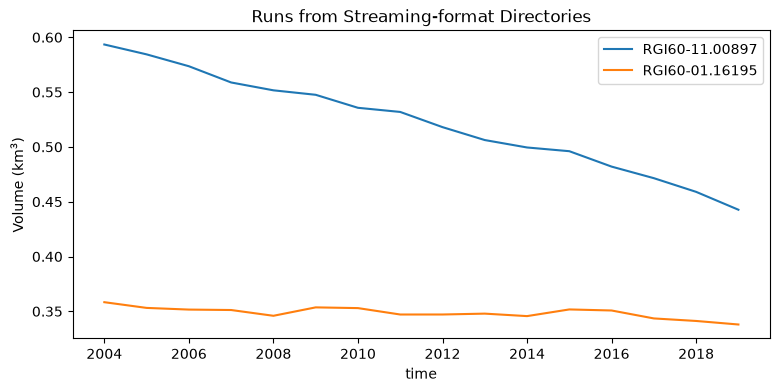

In [11]:
for gd in gdirs:
    tasks.run_from_climate_data(gd, ys=2004, ye=2019, output_filesuffix="_v2run")

plt.figure(figsize=(9, 4))
for gd in gdirs:
    with xr.open_dataset(
        gd.get_filepath("model_diagnostics", filesuffix="_v2run")
    ) as ds:
        (ds.volume_m3 * 1e-9).plot(label=gd.rgi_id)
plt.ylabel("Volume (km$^3$)")
plt.title("Runs from Streaming-format Directories")
plt.legend();

Finally, we restore the real downloader:

In [12]:
_downloads.file_downloader = _original_file_downloader
_downloads._prepro_bundle_format.clear()
cfg.PARAMS["has_internet"] = True
cfg.PARAMS["use_multiprocessing"] = True

2026-09-16 13:42:22: oggm.cfg: PARAMS['has_internet'] changed from `False` to `True`.
2026-09-16 13:42:22: oggm.cfg: Multiprocessing switched ON after user settings.


## Live: a Real v2 Server

A small streaming-format sample dataset (three Svalbard glaciers, levels 0 to 5) is published at `https://cluster.klima.uni-bremen.de/~ngampierakis/test_stream/`. Everything we just did against the simulated server works identically against it, except that the `.zip` probe now hits a real Apache server. Only `RGI60-07.00001`, `RGI60-07.00099`, and `RGI60-07.00100` are available there.

In [13]:
TEST_STREAM_URL = (
    "https://cluster.klima.uni-bremen.de/~ngampierakis/test_stream/"
)

cfg.PATHS["working_dir"] = utils.mkdir(os.path.join(base_dir, "wd_live"))
rid_live = "RGI60-07.00001"

gdirs_live = workflow.init_glacier_directories(
    [rid_live],
    from_prepro_level=4,
    prepro_border=80,
    prepro_rgi_version="62",
    prepro_base_url=TEST_STREAM_URL,
)
gdir_live = gdirs_live[0]
assert gdir_live.has_file("gridded_data")

fls_live = gdir_live.read_store("model_flowlines")
print(f"model_flowlines: {len(fls_live)} flowline(s)")
sorted(f for f in os.listdir(gdir_live.dir) if f.endswith(".manifest.json"))

2026-09-16 13:42:22: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-09-16 13:42:22: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


model_flowlines: 1 flowline(s)


['L3.manifest.json', 'L4.manifest.json']

Two real downloads (the L4 delta and the L3 materialisation, both `.zip`), and the layered directory documents its provenance through the two manifests, exactly as with the simulated server.

## Streaming Without Downloading

So far the bundles were still *downloaded*, at two archives per glacier. The headline feature of the v2 format is that we do not have to: because both zip layers are uncompressed and everything inside is zarr, a client can address any piece of a remote bundle with HTTP range requests.

Two functions in `oggm.utils._downloads` implement this on top of [fsspec](https://filesystem-spec.readthedocs.io):

- `peek_remote_manifest(bundle_url, rgi_id, level)` reads a glacier's level manifest out of a remote bundle.
- `open_remote_group(bundle_url, rgi_id, basename)` lazily opens one zarr group of one glacier as an `xarray.Dataset`. This means only the zip central directories, the consolidated zarr metadata, and the chunks you actually read are transmitted. A deliberately small `block_size` (8 KiB by default) keeps transfers proportional to what is read, whilst `fsspec`'s default 5 MiB read-ahead would download entire bundles.

We read the L3 manifest of a glacier straight off the server:

In [14]:
from oggm.utils._downloads import open_remote_group, peek_remote_manifest

bundle_url = TEST_STREAM_URL + "RGI62/b_080/L3/RGI60-07/RGI60-07.000.zip"

manifest = peek_remote_manifest(bundle_url, rid_live, level=3)
{
    k: manifest[k]
    for k in ("kind", "level", "includes_levels", "requires",
              "format_version", "zarr_groups")
}

{'kind': 'delta',
 'level': 3,
 'includes_levels': [0, 1, 2, 3],
 'requires': [],
 'format_version': 2,
 'zarr_groups': ['climate_historical',
  'downstream_line',
  'gridded_data',
  'inversion_flowlines',
  'inversion_input',
  'inversion_output',
  'model_flowlines']}

For the data itself we lazy-load the glacier's historical climate group inside the remote bundle and pull only the monthly temperature series out of it:

In [15]:
with open_remote_group(bundle_url, rid_live, "climate_historical") as ds:
    temp = ds["temp"]
    ref_hgt = ds.attrs["ref_hgt"]
temp

<xarray.DataArray 'temp' (time: 1428)> Size: 6kB
dask.array<open_dataset-temp, shape=(1428,), dtype=float32, chunksize=(1428,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 11kB 1901-01-01 1901-02-01 ... 2019-12-01
Attributes:
    units:      degC
    long_name:  2m temperature at height ref_hgt

bundle size: 1114 KiB; temperature array read from it: 5.6 KiB


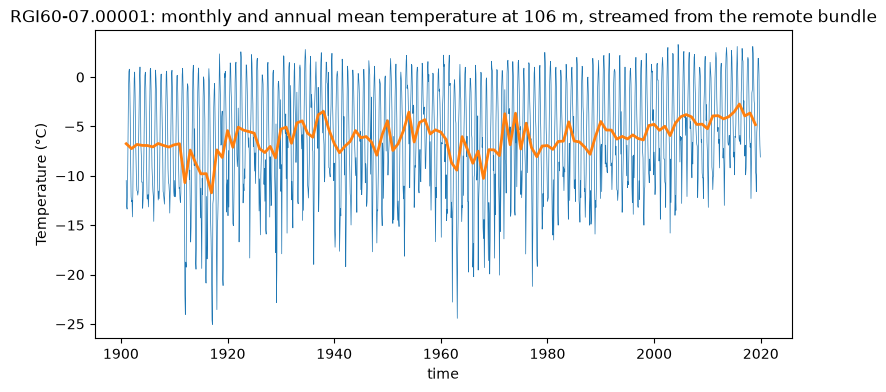

In [16]:
import fsspec

bundle_size = fsspec.filesystem("https").size(bundle_url)
print(
    f"bundle size: {bundle_size / 1024:.0f} KiB; "
    f"temperature array read from it: {temp.nbytes / 1024:.1f} KiB"
)

plt.figure(figsize=(9, 4))
temp.plot(lw=0.5)
temp.resample(time="YS").mean().plot(lw=2)
plt.title(
    f"{rid_live}: monthly and annual mean temperature at {ref_hgt:.0f} m, "
    "streamed from the remote bundle"
)
plt.ylabel("Temperature (\u00b0C)");

The whole bundle (three glaciers, all their L0 to L3 files) never left the server. The reads above fetched the zip central directories, the group's consolidated zarr metadata, and the temperature chunks, which is a few tens of KiB in ranged requests. In the offline test suite, where the served bytes can be counted exactly, reading this group transfers roughly a fifth of the bundle ([`TestStreaming` in oggm/tests/test_gdir_v2.py](../oggm/tests/test_gdir_v2.py)).

**Backwards compatibility:** servers which only publish the classic tar bundles keep working, since the `.zip` probe falls back to `.tar` transparently (see the live test `test_live_bremen_zip_probe_falls_back_to_tar`). v1 directories on disk keep working too, as all the read methods fall back to the `.nc`, pickle, and shapefile files when no v2 file exists.

## Wrap-up

- The streaming format (`format_version: 2`) stores glacier-directory payloads as zarr groups and GeoParquet, packaged in uncompressed zip-in-zip bundles, on top of the unchanged incremental delta and manifest system.
- The user-facing API is unchanged: `init_glacier_directories(..., from_prepro_level=n, prepro_base_url=...)` probes zip-first and falls back to tar. The read methods (`open_group`, `read_store`, and `read_shapefile`) fall back to the legacy file formats.
- `peek_remote_manifest` and `open_remote_group` read manifests and zarr groups straight out of remote bundles via HTTP range requests.
- Published cumulative datasets convert locally, or once server-side, via `compat.convert_prepro_to_deltas(..., convert_to_zarr=True)` followed by `compat.convert_prepro_to_v2_artifacts`.
- The open question is whether the lost compression costs more in bandwidth for users who download whole directories than streaming saves for users who read parts of them.